# 13 — Masking before/after Grad-CAM (qualitative)

Shows Grad-CAM for the three convolutional models, unmasked-trained vs masked-trained weights, on the same images. This is a **qualitative illustration** of how masking changed where each model looks — it accompanies the quantitative accuracy/recall table (notebook 11), which is the primary Objective 3 evidence.

Focused on the convolutional models (Vanilla CNN, Inception, ConvNeXt) where Grad-CAM is meaningful and boundary attention appears. DeiT's Grad-CAM is flat and Swin's is a window lattice, so they are covered in the main XAI chapter, not here.

**Attach:** dataset, 06-build-xai-imageset, 03a (unmasked CNN ckpts), 10a/10b/10c (masked CNN ckpts). GPU on.

In [1]:
import os, torch, torch.nn as nn, numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt, matplotlib.cm as cm
import torchvision.models as tvm
from scipy.ndimage import zoom
NUM_CLASSES=5
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print(device)

cuda


## Exact Grad-CAM class + denorm (from your 07 pipeline)

In [2]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._fwd)
        target_layer.register_full_backward_hook(self._bwd)
    def _fwd(self, m, i, o):
        self.activations = o.detach()
    def _bwd(self, m, gi, go):
        self.gradients = go[0].detach()
    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        inp = input_tensor.requires_grad_(True)
        out = self.model(inp)
        logits = out if isinstance(out, torch.Tensor) else out[0]
        pred_ids = logits.argmax(dim=1)
        targets = pred_ids if target_class is None else torch.full_like(pred_ids, target_class)
        self.model.zero_grad()
        one_hot = torch.zeros_like(logits)
        one_hot[range(len(logits)), targets] = 1.0
        logits.backward(gradient=one_hot)
        a = self.activations
        g = self.gradients
        w = g.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((w*a).sum(dim=1))
        cam = cam - cam.amin(dim=(1,2), keepdim=True)
        cam = cam / (cam.amax(dim=(1,2), keepdim=True) + 1e-8)
        return cam.detach().cpu().numpy(), pred_ids.cpu().numpy(), logits.detach().cpu().numpy()

In [3]:
def denorm(tensor_batch):
    """
    (N,C,H,W) tensor in [0,1] → (N,H,W,3) float numpy in [0,1].
    Uncomment MEAN/STD lines if you add ImageNet normalisation.
    """
    arr = tensor_batch.detach().cpu().permute(0, 2, 3, 1).numpy()
    MEAN = np.array([0.485, 0.456, 0.406])
    STD  = np.array([0.229, 0.224, 0.225])
    arr  = arr * STD + MEAN
    return np.clip(arr, 0, 1)

## Vanilla CNN architecture

In [4]:
class VanillaCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.conv1=nn.Conv2d(3,32,3,padding=1); self.conv2=nn.Conv2d(32,64,3,padding=1)
        self.conv3=nn.Conv2d(64,128,3,padding=1); self.conv4=nn.Conv2d(128,256,3,padding=1)
        self.relu=nn.ReLU(inplace=False); self.maxPool=nn.MaxPool2d(2)
        self.dropout=nn.Dropout(0.25); self.flatten=nn.Flatten()
        self.fc1=nn.Linear(256*14*14,256); self.fc2=nn.Linear(256,num_classes)
    def forward(self,x):
        x=self.relu(self.maxPool(self.conv1(x))); x=self.relu(self.maxPool(self.conv2(x)))
        x=self.relu(self.maxPool(self.conv3(x))); x=self.relu(self.maxPool(self.conv4(x)))
        x=self.flatten(x); x=self.fc1(x); x=self.dropout(x); return self.fc2(x)

## Load frozen images + checkpoint finder

In [5]:
XAISET='/kaggle/input/notebooks/tochyokafor/06-build-xai-imageset'
xai_imgs=np.load(f'{XAISET}/xai_images.npy'); xai_labels=np.load(f'{XAISET}/xai_labels.npy')
class_names=open(f'{XAISET}/xai_class_names.txt').read().splitlines()
imgs=torch.tensor(xai_imgs,dtype=torch.float32).to(device)
imgs_np=denorm(imgs)
def find_ckpt(fname):
    for r,_,fs in os.walk('/kaggle/input'):
        if fname in fs: return os.path.join(r,fname)
    return None
print('frozen set', imgs.shape)

frozen set torch.Size([30, 3, 224, 224])


## Build the before/after figure (one representative image per class)

In [6]:
def get_cams(model, target_layer, x):
    gc=GradCAM(model, target_layer)
    cams,pids,_=gc.generate(x)
    return cams

def overlay(img, cam):
    cam_r = zoom(cam, (img.shape[0]/cam.shape[0], img.shape[1]/cam.shape[1]), order=1)
    cam_r = (cam_r-cam_r.min())/(np.ptp(cam_r)+1e-8)
    heat = cm.jet(cam_r)[...,:3]
    return np.clip(0.5*img+0.5*heat,0,1)

MODELS=[]
# Vanilla
vu=find_ckpt('vanilla_cnn_seed2025.pth'); vm=find_ckpt('vanilla_cnn_masked_seed2025.pth')
# Inception
iu=find_ckpt('inception_v3_seed7.pth'); im=find_ckpt('inception_v3_masked_seed7.pth')
# ConvNeXt
cu=find_ckpt('convnext_tiny_seed99.pth'); cmk=find_ckpt('convnext_tiny_masked_seed99.pth')
print('vanilla',bool(vu),bool(vm),'| inception',bool(iu),bool(im),'| convnext',bool(cu),bool(cmk))

vanilla True True | inception True True | convnext True True


In [7]:
# pick one image per class
sel=[np.where(xai_labels==c)[0][0] for c in range(len(class_names)) if (xai_labels==c).any()]
x_sel=imgs[sel]

def cams_for(builder, ckpt_u, ckpt_m, layer_fn, size=224):
    outs={}
    for tag,ck in [('unmasked',ckpt_u),('masked',ckpt_m)]:
        m=builder(); m.load_state_dict(torch.load(ck,map_location=device)); m=m.to(device).eval()
        for mod in m.modules():
            if isinstance(mod,nn.ReLU): mod.inplace=False
        xx=x_sel
        if size!=224: xx=F.interpolate(x_sel,size=(size,size),mode='bilinear',align_corners=False)
        outs[tag]=get_cams(m, layer_fn(m), xx)
    return outs

def b_van(): return VanillaCNN()
def b_inc():
    m=tvm.inception_v3(weights=None,aux_logits=True,init_weights=False)
    m.fc=nn.Linear(m.fc.in_features,NUM_CLASSES); m.AuxLogits.fc=nn.Linear(m.AuxLogits.fc.in_features,NUM_CLASSES); return m
def b_conv():
    m=tvm.convnext_tiny(weights=None); m.classifier[2]=nn.Linear(m.classifier[2].in_features,NUM_CLASSES); return m

van=cams_for(b_van, vu, vm, lambda m:m.conv4)
inc=cams_for(b_inc, iu, im, lambda m:m.Mixed_7c, size=299)
con=cams_for(b_conv, cu, cmk, lambda m:m.features[7])
print('cams computed')

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


cams computed


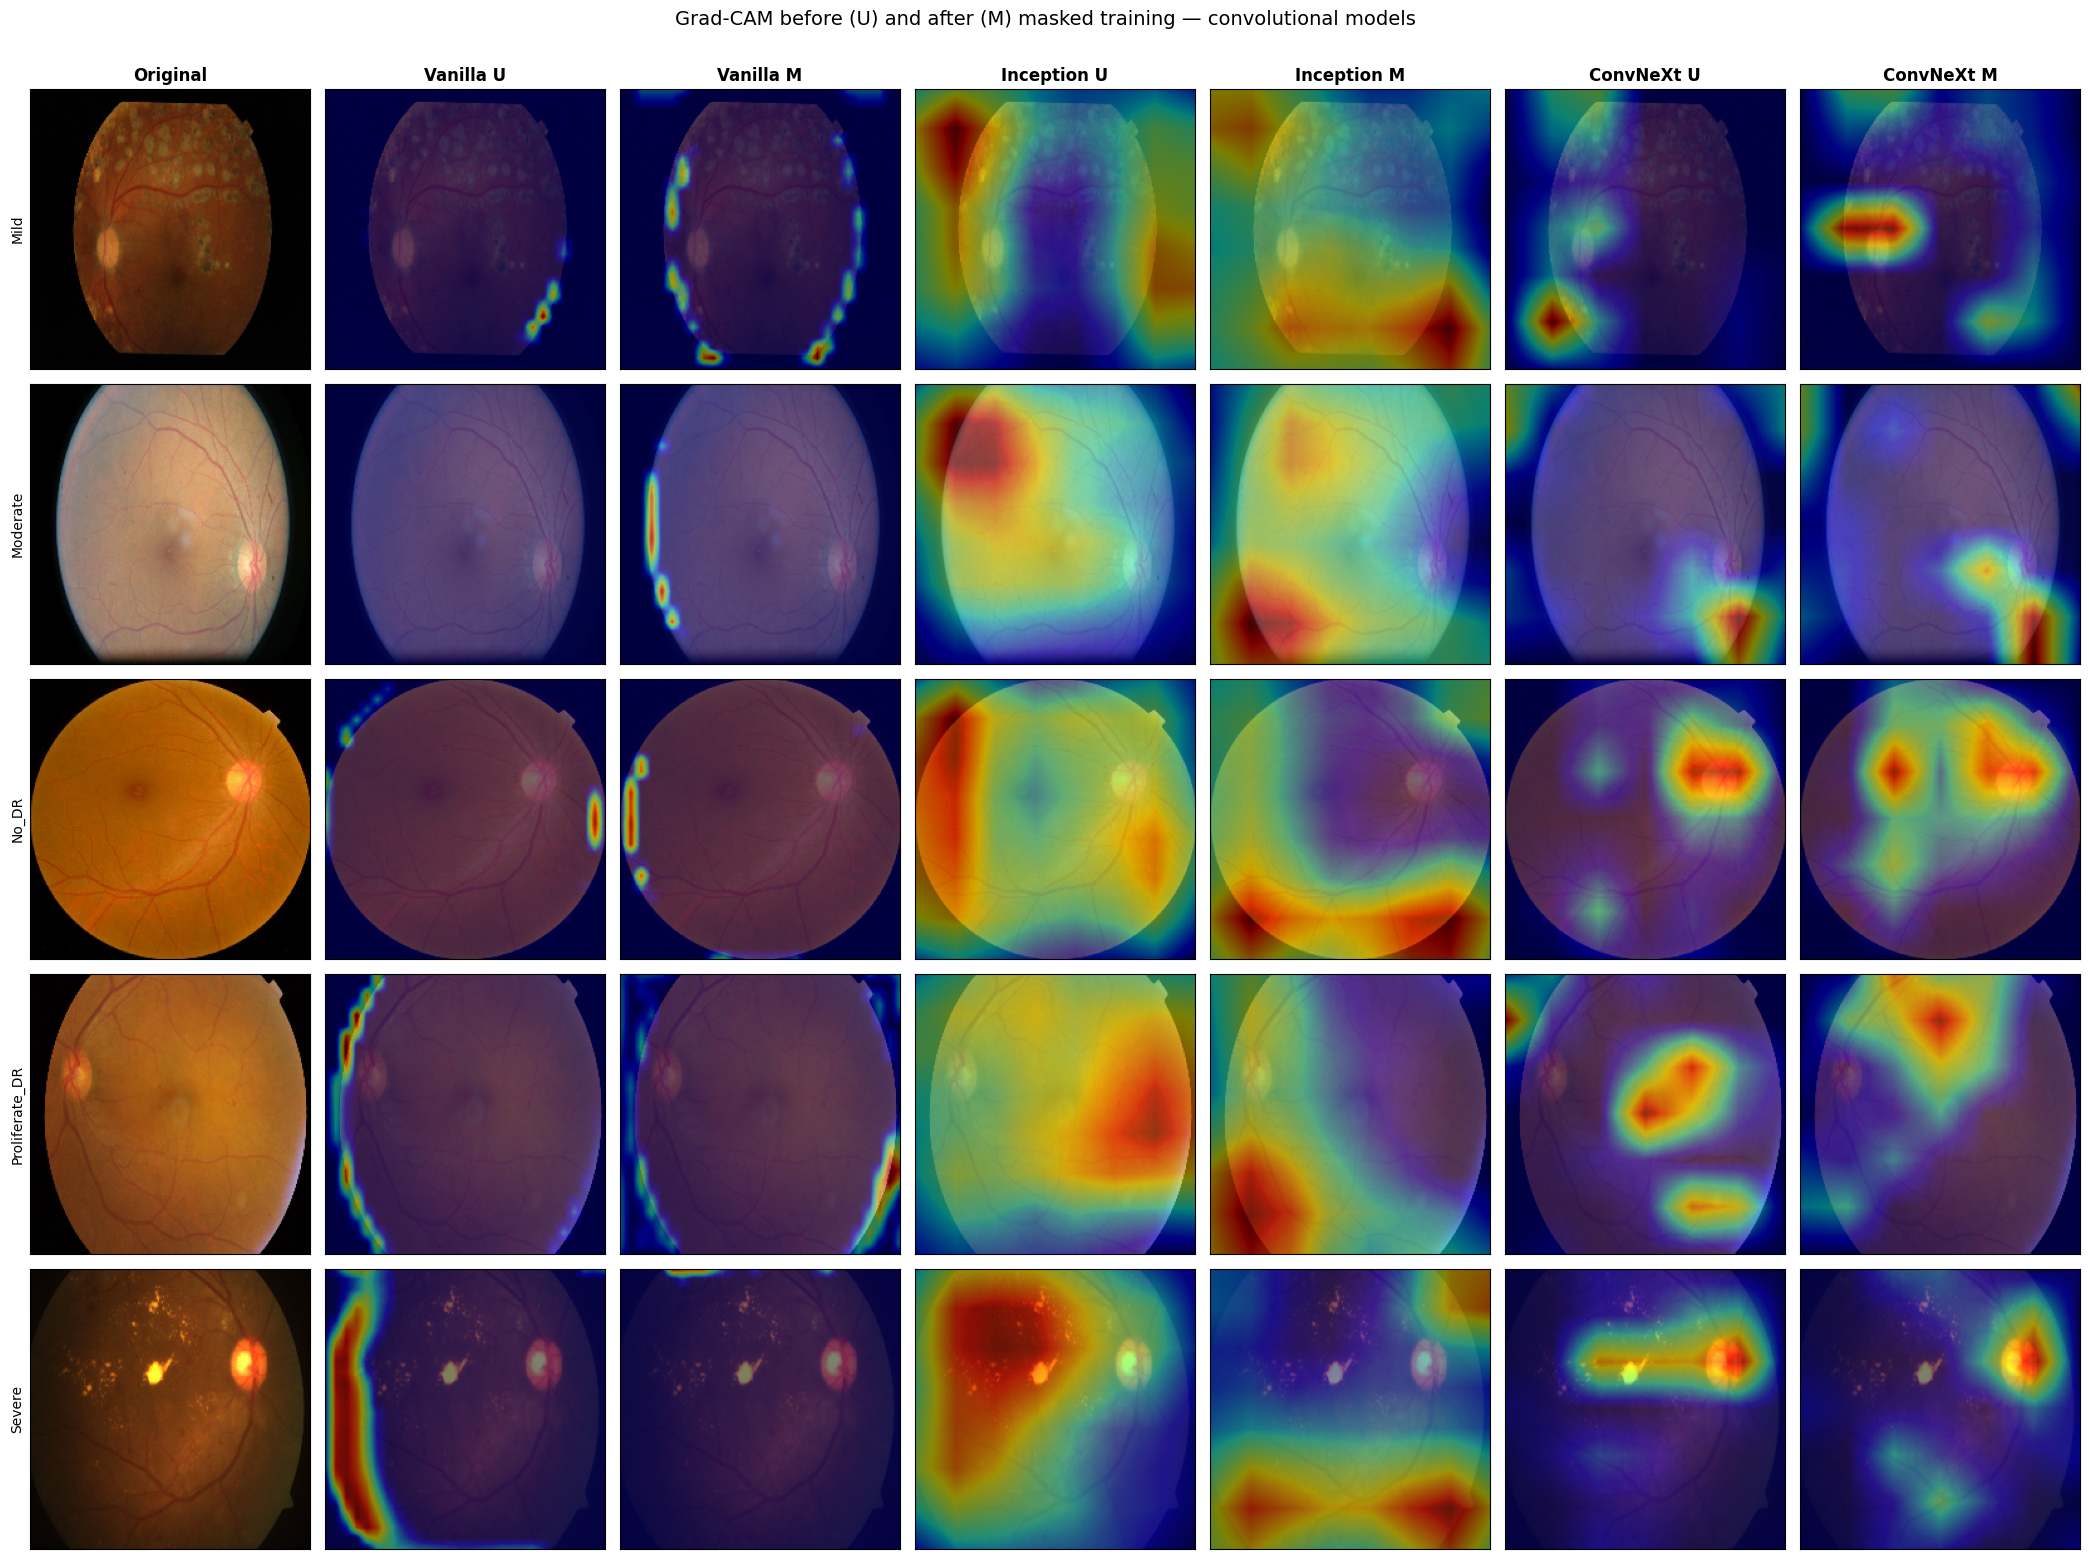

Saved masking_gradcam_comparison.png


In [8]:
# figure: rows = classes, cols = [orig, van U, van M, inc U, inc M, conv U, conv M]
col_titles=['Original','Vanilla U','Vanilla M','Inception U','Inception M','ConvNeXt U','ConvNeXt M']
nrow=len(sel)
fig,axes=plt.subplots(nrow,7,figsize=(21,3.1*nrow))
for j,t in enumerate(col_titles): axes[0,j].set_title(t,fontsize=12,fontweight='bold')
for r in range(nrow):
    img=imgs_np[sel[r]]
    axes[r,0].imshow(img); axes[r,0].set_ylabel(class_names[xai_labels[sel[r]]],fontsize=10)
    axes[r,1].imshow(overlay(img,van['unmasked'][r])); axes[r,2].imshow(overlay(img,van['masked'][r]))
    axes[r,3].imshow(overlay(img,inc['unmasked'][r])); axes[r,4].imshow(overlay(img,inc['masked'][r]))
    axes[r,5].imshow(overlay(img,con['unmasked'][r])); axes[r,6].imshow(overlay(img,con['masked'][r]))
    for a in axes[r]: a.set_xticks([]); a.set_yticks([])
plt.suptitle('Grad-CAM before (U) and after (M) masked training \u2014 convolutional models',fontsize=14,y=1.005)
plt.tight_layout()
plt.savefig('/kaggle/working/masking_gradcam_comparison.png',dpi=200,bbox_inches='tight')
plt.show()
print('Saved masking_gradcam_comparison.png')